# Pima Indians Diabetes: Model Tuning and Ensemble Comparison

This notebook uses the Pima Indians Diabetes Database to build a Decision Tree baseline, evaluate it with 5-fold cross-validation, tune it using both GridSearchCV and RandomizedSearchCV, build a Random Forest ensemble, and compare all results in one table.

Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [1]:
# Import libraries
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 1. Load the dataset

The code automatically finds `diabetes.csv` after the Kaggle dataset is added to the notebook.

In [2]:
possible_paths = [
    'diabetes.csv',
    '/kaggle/input/pima-indians-diabetes-database/diabetes.csv',
    '/kaggle/input/datasets/uciml/pima-indians-diabetes-database/diabetes.csv'
]

csv_path = next((path for path in possible_paths if os.path.exists(path)), None)

if csv_path is None and os.path.exists('/kaggle/input'):
    for folder, _, files in os.walk('/kaggle/input'):
        csv_files = [file for file in files if file.lower().endswith('.csv')]
        if csv_files:
            matching_files = [file for file in csv_files if file.lower() == 'diabetes.csv']
            if not matching_files:
                continue
            csv_path = os.path.join(folder, matching_files[0])
            break

if csv_path is None:
    raise FileNotFoundError('Add the Pima Indians Diabetes dataset, then run this cell again.')

df = pd.read_csv(csv_path)
print('Dataset loaded from:', csv_path)
print('Dataset shape:', df.shape)
df.head()


Dataset loaded from: diabetes.csv
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Understand and clean the data

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
df.describe(include='all').T


Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Zero is medically invalid for these measurements, so treat it as missing.
invalid_zero_columns = [
    'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'
]

for column in invalid_zero_columns:
    if column in df.columns:
        df[column] = df[column].replace(0, np.nan)

print('Cleaned shape:', df.shape)
print('Target counts:')
print(df['Outcome'].value_counts())
print('\nMissing/invalid values handled later by median imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Cleaned shape: (768, 9)
Target counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing/invalid values handled later by median imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 3. Separate features and target, then split

`stratify=y` preserves the target-class proportions in the training and test sets. The test set is kept separate from all tuning.

In [6]:
X = df.drop(columns=['Outcome'])
y = df['Outcome'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)


Training shape: (614, 8)
Testing shape: (154, 8)


## 4. Build a leakage-safe preprocessing pipeline

In [7]:
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(exclude=np.number).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numbers', numerical_pipeline, numerical_columns),
    ('categories', categorical_pipeline, categorical_columns)
])

print('Numerical columns:', numerical_columns)
print('Categorical columns:', categorical_columns)


Numerical columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Categorical columns: []


## 5. Define evaluation helpers

F1-score is the primary metric because it balances precision and recall. The same untouched test set is used for the final comparison.

In [8]:
def test_metrics(model, model_name, search_method, cv_f1=np.nan, training_seconds=np.nan):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        'Model': model_name,
        'Method': search_method,
        'CV F1 Mean': cv_f1,
        'Test Accuracy': accuracy_score(y_test, predictions),
        'Test Precision': precision_score(y_test, predictions, zero_division=0),
        'Test Recall': recall_score(y_test, predictions, zero_division=0),
        'Test F1': f1_score(y_test, predictions, zero_division=0),
        'Test ROC-AUC': roc_auc_score(y_test, probabilities),
        'Training Time (s)': training_seconds
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

all_results = []


## 6. Baseline Decision Tree with 5-fold cross-validation

In [9]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced'))
])

start = time.time()
baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_pipeline.fit(X_train, y_train)
baseline_time = time.time() - start

baseline_cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    '5-Fold Mean': [
        baseline_cv['test_accuracy'].mean(),
        baseline_cv['test_precision'].mean(),
        baseline_cv['test_recall'].mean(),
        baseline_cv['test_f1'].mean(),
        baseline_cv['test_roc_auc'].mean()
    ],
    'Standard Deviation': [
        baseline_cv['test_accuracy'].std(),
        baseline_cv['test_precision'].std(),
        baseline_cv['test_recall'].std(),
        baseline_cv['test_f1'].std(),
        baseline_cv['test_roc_auc'].std()
    ]
})

all_results.append(test_metrics(
    baseline_pipeline,
    'Decision Tree',
    'Baseline + 5-Fold CV',
    baseline_cv['test_f1'].mean(),
    baseline_time
))

baseline_cv_summary.round(4)


,Metric,5-Fold Mean,Standard Deviation
0,Accuracy,0.6792,0.0377
1,Precision,0.5408,0.0517
2,Recall,0.5518,0.0464
3,F1,0.5457,0.0462
4,ROC-AUC,0.6497,0.0382


## 7. Tune with GridSearchCV

GridSearchCV evaluates every parameter combination using 5-fold cross-validation.

In [10]:
grid_parameters = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 8, 12, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=grid_parameters,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True
)

start = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print('Best GridSearchCV parameters:')
print(grid_search.best_params_)
print('Best cross-validation F1:', round(grid_search.best_score_, 4))

all_results.append(test_metrics(
    grid_search.best_estimator_,
    'Decision Tree',
    'GridSearchCV',
    grid_search.best_score_,
    grid_time
))


Best GridSearchCV parameters:
{'model__criterion': 'gini', 'model__max_depth': 8, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}
Best cross-validation F1: 0.669


## 8. Tune with RandomizedSearchCV

RandomizedSearchCV tests a fixed number of randomly selected combinations. It is often faster when the search space is large.

In [11]:
random_parameters = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': list(range(2, 21)) + [None],
    'model__min_samples_split': list(range(2, 21)),
    'model__min_samples_leaf': list(range(1, 21)),
    'model__max_features': [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=random_parameters,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

start = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start

print('Best RandomizedSearchCV parameters:')
print(random_search.best_params_)
print('Best cross-validation F1:', round(random_search.best_score_, 4))

all_results.append(test_metrics(
    random_search.best_estimator_,
    'Decision Tree',
    'RandomizedSearchCV',
    random_search.best_score_,
    random_time
))


Best RandomizedSearchCV parameters:
{'model__min_samples_split': 20, 'model__min_samples_leaf': 16, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__criterion': 'log_loss'}
Best cross-validation F1: 0.6524


## 9. Build a Random Forest ensemble

Random Forest combines many decision trees trained on different bootstrap samples and feature subsets. Averaging their predictions usually reduces the variance of a single tree.

In [12]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

start = time.time()
forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

random_forest_pipeline.fit(X_train, y_train)
forest_time = time.time() - start

all_results.append(test_metrics(
    random_forest_pipeline,
    'Random Forest',
    'Ensemble + 5-Fold CV',
    forest_cv['test_f1'].mean(),
    forest_time
))


## 10. Compare all results in one table

In [13]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test F1', ascending=False).reset_index(drop=True)

styled_results = results_df.round(4)
styled_results


,Model,Method,CV F1 Mean,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time (s)
0,Decision Tree,GridSearchCV,0.6690,0.7468,0.6271,0.6852,0.6549,0.8036,11.9418
1,Random Forest,Ensemble + 5-Fold CV,0.6871,0.7468,0.6316,0.6667,0.6486,0.8244,2.7522
2,Decision Tree,RandomizedSearchCV,0.6524,0.7078,0.5957,0.5185,0.5545,0.7675,3.2975
3,Decision Tree,Baseline + 5-Fold CV,0.5457,0.7143,0.6190,0.4815,0.5417,0.6607,2.4907


## 11. Confusion matrices for all final models

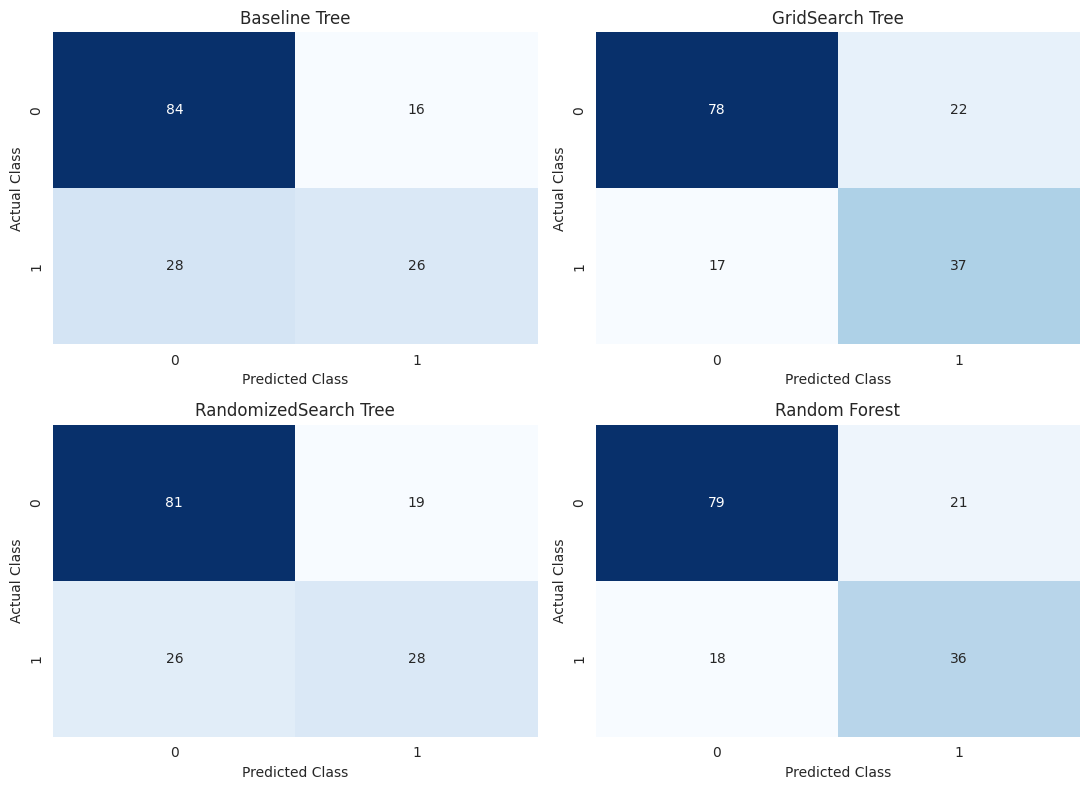

In [14]:
final_models = {
    'Baseline Tree': baseline_pipeline,
    'GridSearch Tree': grid_search.best_estimator_,
    'RandomizedSearch Tree': random_search.best_estimator_,
    'Random Forest': random_forest_pipeline
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for axis, (name, model) in zip(axes.ravel(), final_models.items()):
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(name)
    axis.set_xlabel('Predicted Class')
    axis.set_ylabel('Actual Class')

plt.tight_layout()
plt.show()


## 12. Select and justify the best model

In [15]:
best_row = results_df.iloc[0]

print('Best final model:', best_row['Model'])
print('Method:', best_row['Method'])
print('Test F1:', round(best_row['Test F1'], 4))
print('Test Recall:', round(best_row['Test Recall'], 4))
print('Test Precision:', round(best_row['Test Precision'], 4))
print('Test ROC-AUC:', round(best_row['Test ROC-AUC'], 4))

print(f"\nConclusion: {best_row['Model']} using {best_row['Method']} is selected "
      f"because it achieved the highest F1-score ({best_row['Test F1']:.4f}) "
      "on the untouched test set. F1-score is the main metric here because the "
      "target is imbalanced and both false positives and false negatives matter. "
      "Recall and ROC-AUC are also checked before making the final decision.")


Best final model: Decision Tree
Method: GridSearchCV
Test F1: 0.6549
Test Recall: 0.6852
Test Precision: 0.6271
Test ROC-AUC: 0.8036

Conclusion: Decision Tree using GridSearchCV is selected because it achieved the highest F1-score (0.6549) on the untouched test set. F1-score is the main metric here because the target is imbalanced and both false positives and false negatives matter. Recall and ROC-AUC are also checked before making the final decision.


## Interview Summary

- I first built a Decision Tree baseline.
- I used stratified 5-fold cross-validation for a more stable performance estimate.
- GridSearchCV exhaustively tested a defined parameter grid.
- RandomizedSearchCV sampled combinations from a wider search space with fewer evaluations.
- I built Random Forest as the ensemble model to reduce the variance of a single tree.
- I compared every final model on the same untouched test set and selected the model with the highest F1-score, while also reviewing recall and ROC-AUC.